# Can the model even tell left from right?

**The question, in one sentence:** MDM turns your caption into a single vector before it generates
any motion — so if that vector is nearly identical for *"raise your **left** arm"* and *"raise your
**right** arm"*, the generator was never told which one you asked for.

This notebook checks whether that is actually the case, using the real encoder from the real
pipeline. **No model is trained. Nothing is generated.** We only ask what the conditioning signal
contains.

## The intuition

Text-to-motion models do not read your sentence. They read a **vector** — a list of 512 numbers
that stands in for your sentence. Everything the generator knows about what you asked for has to
survive that compression.

```
   "a person raises their left arm"
                 |
                 v
        +------------------+
        |  CLIP  ViT-B/32  |     <-- frozen. never trained on motion.
        +------------------+
                 |
                 v
        [ 0.31, -0.02, ..., 0.88 ]      512 numbers
                 |
                 v
        +------------------+
        |  diffusion model |     <-- sees ONLY this vector
        +------------------+
                 |
                 v
             the motion
```

So here is the test. Take two sentences that differ by **exactly one word**, where that word
changes the meaning completely:

| | |
|---|---|
| A | a person raises their **left** arm |
| B | a person raises their **right** arm |

Push both through the encoder and measure how similar the two vectors are, using **cosine
similarity** — 1.00 means "identical direction", lower means "further apart".

**If A and B come out nearly identical, the generator physically cannot distinguish them.** Not
because it is undertrained, not because the dataset is small — the information is already gone
before the generator sees anything.

### First, load the real encoder — the exact code path `model/mdm.py` uses

In [1]:
import os
import sys

MDM_ROOT = os.path.join("..", "third_party", "motion-diffusion-model")
sys.path.insert(0, os.path.abspath(MDM_ROOT))

import numpy as np
import torch
import clip
from scipy import stats

torch.manual_seed(0)
print("torch:", torch.__version__)
print("clip available models:", clip.available_models())

torch: 2.13.0
clip available models: ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']


In [2]:
def load_and_freeze_clip(clip_version):
    # Copied verbatim from third_party/motion-diffusion-model/model/mdm.py::MDM.load_and_freeze_clip
    clip_model, clip_preprocess = clip.load(clip_version, device='cpu', jit=False)
    clip.model.convert_weights(clip_model)
    clip_model.eval()
    for p in clip_model.parameters():
        p.requires_grad = False
    return clip_model


def clip_encode_text(clip_model, raw_text, dataset="humanml"):
    # Copied verbatim from third_party/motion-diffusion-model/model/mdm.py::MDM.clip_encode_text
    device = "cpu"
    max_text_len = 20 if dataset in ["humanml", "kit"] else None
    if max_text_len is not None:
        default_context_length = 77
        context_length = max_text_len + 2
        assert context_length < default_context_length
        texts = clip.tokenize(raw_text, context_length=context_length, truncate=True).to(device)
        zero_pad = torch.zeros([texts.shape[0], default_context_length - context_length],
                                dtype=texts.dtype, device=texts.device)
        texts = torch.cat([texts, zero_pad], dim=1)
    else:
        texts = clip.tokenize(raw_text, truncate=True).to(device)
    with torch.no_grad():
        return clip_model.encode_text(texts).float()


clip_model = load_and_freeze_clip("ViT-B/32")
print("CLIP text encoder loaded and frozen.")

CLIP text encoder loaded and frozen.


### Calibrating your eye: what *is* a high cosine similarity?

Before any statistics, a reader needs a scale. Cosine similarity between sentence embeddings is
**not** spread over 0 to 1 the way intuition suggests — CLIP packs ordinary English sentences into
a narrow cone, so almost everything scores high. The cell below anchors the scale with four
reference points so the later numbers mean something.

## The setup — three matched groups

One comparison is not enough, because a high similarity score has two possible explanations and we
have to separate them.

```
  GROUP              what changes between the two sentences        purpose
  ----------------------------------------------------------------------------------
  spatial            left -> right, forward -> backward            the thing being tested
                     (a MODIFIER)

  non-spatial        walks -> runs, sits -> stands                 first control:
  verb               (a VERB)                                      does CLIP separate anything?

  non-spatial        slowly -> quickly, red -> blue                second control, and the
  modifier           (a MODIFIER, same word class as spatial)      LOAD-BEARING one
```

The third group is what makes the result mean anything. Without it, *"CLIP is blind to **spatial**
language"* and the far weaker *"CLIP separates **verbs** better than **modifiers** in general"*
predict identical numbers. Comparing spatial modifiers against non-spatial **modifiers** holds word
class constant, so only spatial-ness varies.

In [3]:
SPATIAL_PAIRS_PILOT = [
    ("a person raises their left arm", "a person raises their right arm"),
    ("a person turns left", "a person turns right"),
    ("a person walks forward", "a person walks backward"),
    ("a person steps over the box", "a person steps around the box"),
    ("a person kicks with their left leg", "a person kicks with their right leg"),
    ("a person moves forward", "a person moves backward"),
    ("a person walks to the left", "a person walks to the right"),
    ("a person raises their left hand", "a person raises their right hand"),
    ("a person leans forward", "a person leans backward"),
    ("a person jumps forward", "a person jumps backward"),
    ("a person waves with their left hand", "a person waves with their right hand"),
    ("a person spins clockwise", "a person spins counterclockwise"),
    ("a person steps forward", "a person steps backward"),
    ("a person reaches with their left arm", "a person reaches with their right arm"),
    ("a person walks in front of the chair", "a person walks behind the chair"),
    ("a person bends their left knee", "a person bends their right knee"),
]

SPATIAL_PAIRS_EXPANSION = [
    ("the person points to the left", "the person points to the right"),
    ("a person swings their left arm", "a person swings their right arm"),
    ("a person tilts their head left", "a person tilts their head right"),
    ("a person crouches and moves forward", "a person crouches and moves backward"),
    ("a person hops to the left side", "a person hops to the right side"),
    ("a person extends their left leg", "a person extends their right leg"),
    ("a person circles clockwise around the room", "a person circles counterclockwise around the room"),
    ("a person shifts their weight to the left", "a person shifts their weight to the right"),
    ("a person steps in front of the table", "a person steps behind the table"),
    ("a person drags their left foot", "a person drags their right foot"),
    ("a person twists to the left", "a person twists to the right"),
    ("a person marches forward in a line", "a person marches backward in a line"),
    ("a person lifts their left shoulder", "a person lifts their right shoulder"),
    ("a person walks backward slowly", "a person walks forward slowly"),
    ("a person rotates their body clockwise", "a person rotates their body counterclockwise"),
    ("a person stretches their left arm out", "a person stretches their right arm out"),
    ("a person moves to the left quickly", "a person moves to the right quickly"),
    ("a person kicks forward with force", "a person kicks backward with force"),
    ("a person glances to the left", "a person glances to the right"),
    ("a person stands behind the door", "a person stands in front of the door"),
    ("a person hops forward twice", "a person hops backward twice"),
    ("a person pivots on their left foot", "a person pivots on their right foot"),
    ("a person raises their left knee high", "a person raises their right knee high"),
    ("a person leans their body left", "a person leans their body right"),
]

NONSPATIAL_VERB_PAIRS_PILOT = [
    ("a person walks forward", "a person runs forward"),
    ("a person sits on a chair", "a person stands on a chair"),
    ("a person waves with their hand", "a person claps with their hand"),
    ("a person kicks the ball", "a person throws the ball"),
    ("a person picks up the box", "a person drops the box"),
    ("a person walks quickly", "a person walks slowly"),
    ("a person jumps once", "a person jumps twice"),
    ("a person sits on the chair", "a person sits on the table"),
    ("a person claps their hands", "a person waves their hands"),
    ("a person walks forward", "a person skips forward"),
    ("a person reads a book", "a person writes a letter"),
    ("a person opens the door", "a person closes the door"),
    ("a person drinks water", "a person eats food"),
    ("a person plays the guitar", "a person plays the piano"),
    ("a person laughs loudly", "a person cries softly"),
    ("a person dances happily", "a person dances sadly"),
]

NONSPATIAL_VERB_PAIRS_EXPANSION = [
    ("a person bakes a cake", "a person cooks a meal"),
    ("a person sweeps the floor", "a person mops the floor"),
    ("a person paints the wall", "a person cleans the wall"),
    ("a person ties their shoes", "a person removes their shoes"),
    ("a person folds the clothes", "a person washes the clothes"),
    ("a person waters the plant", "a person trims the plant"),
    ("a person types on the keyboard", "a person clicks the mouse"),
    ("a person hums a tune", "a person whistles a tune"),
    ("a person nods their head", "a person shakes their head"),
    ("a person yawns quietly", "a person sneezes quietly"),
    ("a person stretches their body", "a person relaxes their body"),
    ("a person balances on one foot", "a person hops on one foot"),
    ("a person catches the frisbee", "a person throws the frisbee"),
    ("a person unwraps the gift", "a person wraps the gift"),
    ("a person waves goodbye", "a person bows goodbye"),
    ("a person sharpens the pencil", "a person breaks the pencil"),
    ("a person feeds the dog", "a person walks the dog"),
    ("a person answers the phone", "a person ignores the phone"),
    ("a person locks the door", "a person unlocks the door"),
    ("a person tastes the soup", "a person stirs the soup"),
    ("a person signs the paper", "a person reads the paper"),
    ("a person lifts the weight", "a person drops the weight"),
    ("a person hugs their friend", "a person greets their friend"),
    ("a person whispers a secret", "a person shouts a secret"),
]

NONSPATIAL_MODIFIER_PAIRS_PILOT = [
    ("a person raises their arm slowly", "a person raises their arm quickly"),
    ("a person walks slowly", "a person walks quickly"),
    ("a person raises their broken arm", "a person raises their injured arm"),
    ("a person kicks the red ball", "a person kicks the blue ball"),
    ("a person wears a blue shirt", "a person wears a red shirt"),
    ("a person picks up the small box", "a person picks up the large box"),
    ("a person carries a heavy bag", "a person carries a light bag"),
    ("a person claps their hands loudly", "a person claps their hands softly"),
    ("a person sits on the wooden chair", "a person sits on the metal chair"),
    ("a person throws the heavy ball", "a person throws the light ball"),
    ("a person dances gracefully", "a person dances clumsily"),
    ("a person raises their tired arm", "a person raises their strong arm"),
    ("a person walks on the wet floor", "a person walks on the dry floor"),
    ("a person holds the empty cup", "a person holds the full cup"),
    ("a person wears an old hat", "a person wears a new hat"),
    ("a person speaks quietly", "a person speaks loudly"),
]

NONSPATIAL_MODIFIER_PAIRS_EXPANSION = [
    ("a person wears a striped shirt", "a person wears a plain shirt"),
    ("a person eats a spicy meal", "a person eats a bland meal"),
    ("a person sits in a comfortable chair", "a person sits in an uncomfortable chair"),
    ("a person carries a fragile vase", "a person carries a sturdy vase"),
    ("a person drives an expensive car", "a person drives a cheap car"),
    ("a person reads a thick book", "a person reads a thin book"),
    ("a person wears a tight jacket", "a person wears a loose jacket"),
    ("a person paints a colorful picture", "a person paints a dull picture"),
    ("a person tells a funny joke", "a person tells a serious joke"),
    ("a person walks with a confident stride", "a person walks with a nervous stride"),
    ("a person holds a warm cup", "a person holds a cold cup"),
    ("a person wears a shiny ring", "a person wears a dull ring"),
    ("a person plays a difficult song", "a person plays an easy song"),
    ("a person climbs a steep hill", "a person climbs a gentle hill"),
    ("a person tells a short story", "a person tells a long story"),
    ("a person buys a fresh apple", "a person buys a rotten apple"),
    ("a person wears a formal dress", "a person wears a casual dress"),
    ("a person builds a tall tower", "a person builds a short tower"),
    ("a person sings a cheerful song", "a person sings a gloomy song"),
    ("a person eats a sweet candy", "a person eats a sour candy"),
    ("a person wears a heavy coat", "a person wears a thin coat"),
    ("a person drinks a hot coffee", "a person drinks a cold coffee"),
    ("a person owns a modern house", "a person owns an old house"),
    ("a person gives a clear explanation", "a person gives a confusing explanation"),
]

SPATIAL_PAIRS = SPATIAL_PAIRS_PILOT + SPATIAL_PAIRS_EXPANSION
NONSPATIAL_VERB_PAIRS = NONSPATIAL_VERB_PAIRS_PILOT + NONSPATIAL_VERB_PAIRS_EXPANSION
NONSPATIAL_MODIFIER_PAIRS = NONSPATIAL_MODIFIER_PAIRS_PILOT + NONSPATIAL_MODIFIER_PAIRS_EXPANSION

print(f"Spatial: {len(SPATIAL_PAIRS)} ({len(SPATIAL_PAIRS_PILOT)} pilot + {len(SPATIAL_PAIRS_EXPANSION)} expansion)")
print(f"Nonspatial-verb: {len(NONSPATIAL_VERB_PAIRS)} ({len(NONSPATIAL_VERB_PAIRS_PILOT)} pilot + {len(NONSPATIAL_VERB_PAIRS_EXPANSION)} expansion)")
print(f"Nonspatial-modifier: {len(NONSPATIAL_MODIFIER_PAIRS)} ({len(NONSPATIAL_MODIFIER_PAIRS_PILOT)} pilot + {len(NONSPATIAL_MODIFIER_PAIRS_EXPANSION)} expansion)")

Spatial: 40 (16 pilot + 24 expansion)
Nonspatial-verb: 40 (16 pilot + 24 expansion)
Nonspatial-modifier: 40 (16 pilot + 24 expansion)


In [4]:
def cosine_sim(a, b):
    a = a / a.norm(dim=-1, keepdim=True)
    b = b / b.norm(dim=-1, keepdim=True)
    return float((a * b).sum(dim=-1))


def pair_similarities(pairs):
    sims = []
    for s1, s2 in pairs:
        e1 = clip_encode_text(clip_model, [s1])
        e2 = clip_encode_text(clip_model, [s2])
        sims.append(cosine_sim(e1[0], e2[0]))
    return np.array(sims)


spatial_sims = pair_similarities(SPATIAL_PAIRS)
verb_sims = pair_similarities(NONSPATIAL_VERB_PAIRS)
modifier_sims = pair_similarities(NONSPATIAL_MODIFIER_PAIRS)

print(f"Computed {len(spatial_sims)} spatial, {len(verb_sims)} verb, {len(modifier_sims)} modifier similarities.")
print(f"Spatial mean so far: {spatial_sims.mean():.4f}, pilot-only mean: {spatial_sims[:16].mean():.4f}")

Computed 40 spatial, 40 verb, 40 modifier similarities.
Spatial mean so far: 0.9707, pilot-only mean: 0.9654


In [5]:
# cosine_sim is defined again in the measurement section below (identical body);
# defined here so the calibration can run before the reader meets the full machinery.
def cosine_sim(a, b):
    a = a / a.norm(dim=-1, keepdim=True)
    b = b / b.norm(dim=-1, keepdim=True)
    return float((a * b).sum(dim=-1))

anchors = [
    ("identical sentences",
     "a person raises their left arm", "a person raises their left arm"),
    ("SPATIAL pair (left/right)",
     "a person raises their left arm", "a person raises their right arm"),
    ("non-spatial modifier (slow/fast)",
     "a person raises their arm slowly", "a person raises their arm quickly"),
    ("different action entirely",
     "a person raises their left arm", "a person sits down on a chair"),
    ("unrelated topic",
     "a person raises their left arm", "the stock market closed lower on Tuesday"),
]
print(f"{'reference point':<36} {'cosine':>8}")
print("-" * 46)
anchor_vals = {}
for label, s1, s2 in anchors:
    v = cosine_sim(clip_encode_text(clip_model, [s1])[0], clip_encode_text(clip_model, [s2])[0])
    anchor_vals[label] = v
    print(f"{label:<36} {v:>8.4f}")
print()
print("But a single example is not evidence. Here is where the GROUPS actually land,")
print("computed further down this notebook over 40 pairs each:")
print(f"{'  spatial group mean (n=40)':<36} {spatial_sims.mean():>8.4f}")
print(f"{'  non-spatial modifier mean (n=40)':<36} {modifier_sims.mean():>8.4f}")
print()
print("Note the reversal: the ONE slow/fast example above scores HIGHER than the ONE")
print("left/right example, which is the opposite of the group result. That is not a")
print("contradiction -- it is why this study uses 40 pairs per group instead of anecdotes.")


reference point                        cosine
----------------------------------------------
identical sentences                    1.0000
SPATIAL pair (left/right)              0.9699
non-spatial modifier (slow/fast)       0.9890
different action entirely              0.7814


unrelated topic                        0.7190

But a single example is not evidence. Here is where the GROUPS actually land,
computed further down this notebook over 40 pairs each:
  spatial group mean (n=40)            0.9707
  non-spatial modifier mean (n=40)     0.9442

Note the reversal: the ONE slow/fast example above scores HIGHER than the ONE
left/right example, which is the opposite of the group result. That is not a
contradiction -- it is why this study uses 40 pairs per group instead of anecdotes.


### Calibrating your eye: what *is* a high cosine similarity?

Read that table before going further, because it reframes everything below.

A sentence about **the stock market** still scores 0.72 against a sentence about raising an arm.
CLIP compresses ordinary English into a narrow band near the top of the scale, so a gap of 0.03
between two groups is **not** the rounding error it looks like — it is a large fraction of the
range the encoder actually uses.

**And notice the reversal in that output.** The single *slow/fast* example scores **higher** than
the single *left/right* example — the opposite of the group-level result. Single examples are
noisy. If this notebook had been built on hand-picked sentence pairs, it could have argued either
side with equal conviction. That is precisely why the study below uses 40 pairs per group, a
control group, and a significance test, rather than a demonstration.

It is also why *"is 0.97 high?"* is the wrong question. The answerable one is *"is 0.97 higher
than a **comparable non-spatial** pair?"*


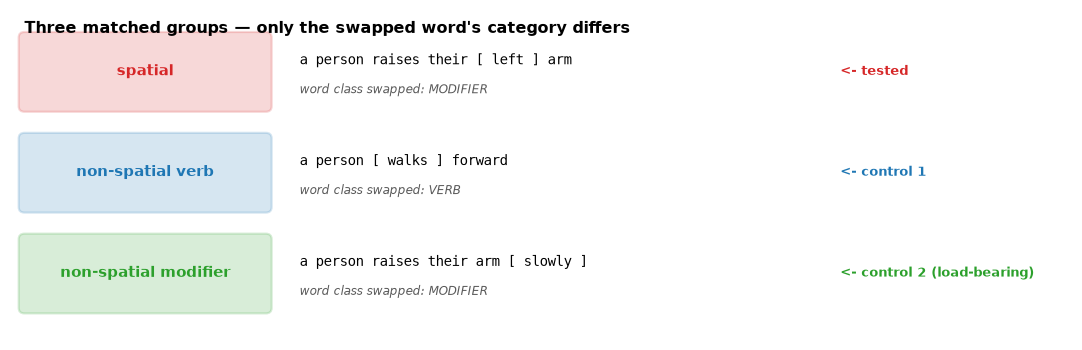

In [6]:
# Design diagram: what varies in each group, drawn rather than described
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.set_xlim(0, 11); ax.set_ylim(0, 3.6); ax.axis("off")
rows = [
    (2.55, "spatial",             "a person raises their [ left ] arm",   "MODIFIER",  "tab:red",   "<- tested"),
    (1.45, "non-spatial verb",    "a person [ walks ] forward",           "VERB",      "tab:blue",  "<- control 1"),
    (0.35, "non-spatial modifier","a person raises their arm [ slowly ]", "MODIFIER",  "tab:green", "<- control 2 (load-bearing)"),
]
for y, name, example, wclass, color, note in rows:
    ax.add_patch(FancyBboxPatch((0.15, y), 2.5, 0.75, boxstyle="round,pad=0.06",
                                facecolor=color, alpha=0.18, edgecolor=color, linewidth=1.6))
    ax.text(1.40, y + 0.38, name, ha="center", va="center", fontsize=10.5, weight="bold", color=color)
    ax.text(3.0, y + 0.50, example, ha="left", va="center", fontsize=10, family="monospace")
    ax.text(3.0, y + 0.18, f"word class swapped: {wclass}", ha="left", va="center",
            fontsize=8.5, style="italic", color="0.35")
    ax.text(8.6, y + 0.38, note, ha="left", va="center", fontsize=9, color=color, weight="bold")
ax.text(0.15, 3.35, "Three matched groups — only the swapped word's category differs",
        fontsize=11.5, weight="bold")
plt.tight_layout(); plt.savefig("01_fig_design.png", dpi=110); plt.show()

## Power analysis — decided *before* looking at the full sample

A pilot of 16 pairs per group suggested an effect. Rather than report that pilot as a result, we use
its effect size to work out how many pairs are actually needed, then collect that many.

This ordering matters. Running a test, finding p just above 0.05, and then adding data until it
drops below is one of the standard ways to fool yourself. The target n is fixed here, before the
full-sample comparison runs.

In [7]:
pilot_spatial = np.array(pair_similarities(SPATIAL_PAIRS_PILOT))
pilot_modifier = np.array(pair_similarities(NONSPATIAL_MODIFIER_PAIRS_PILOT))

n1, n2 = len(pilot_spatial), len(pilot_modifier)
pooled_sd = np.sqrt(((n1-1)*pilot_spatial.std(ddof=1)**2 + (n2-1)*pilot_modifier.std(ddof=1)**2) / (n1+n2-2))
pilot_d = (pilot_spatial.mean() - pilot_modifier.mean()) / pooled_sd
print(f"Pilot (n={n1}/group) direct Cohen's d (spatial vs modifier): {pilot_d:.3f}")

try:
    from statsmodels.stats.power import TTestIndPower
    power_calc = TTestIndPower()
    for power_target in [0.80, 0.95]:
        n_needed = power_calc.solve_power(effect_size=pilot_d, power=power_target, alpha=0.05, alternative='larger')
        print(f"  n/group needed for {int(power_target*100)}% power (one-sided alpha=0.05): {n_needed:.1f}")
    power_at_40 = power_calc.solve_power(effect_size=pilot_d, nobs1=40, alpha=0.05, alternative='larger')
    print(f"  achieved power at n=40/group: {power_at_40:.3f}")
except ImportError:
    print("statsmodels not installed -- reporting effect size only, no power curve.")

BONFERRONI_ALPHA = 0.05 / 3  # three pairwise comparisons run below
print(f"\nBonferroni-corrected alpha for 3 pairwise comparisons: {BONFERRONI_ALPHA:.4f}")

Pilot (n=16/group) direct Cohen's d (spatial vs modifier): 0.678


  n/group needed for 80% power (one-sided alpha=0.05): 27.6
  n/group needed for 95% power (one-sided alpha=0.05): 47.8
  achieved power at n=40/group: 0.913

Bonferroni-corrected alpha for 3 pairwise comparisons: 0.0167


## The measurement

Every comparison below reports **both** one-sided and two-sided p-values, plus the Bonferroni
threshold for the three pairwise tests being run. One-sided is the pre-registered direction; the
two-sided number is shown alongside so nothing rests on that choice going unnoticed.

In [8]:
def describe(name, arr):
    print("%-20s (n=%2d): mean=%.4f  std=%.4f  min=%.4f  max=%.4f" % (
        name, len(arr), arr.mean(), arr.std(ddof=1), arr.min(), arr.max()))

describe("Spatial", spatial_sims)
describe("Nonspatial-verb", verb_sims)
describe("Nonspatial-modifier", modifier_sims)

h_stat, h_p = stats.kruskal(spatial_sims, verb_sims, modifier_sims)
print(f"\nKruskal-Wallis (all 3 groups, n=40 each): H={h_stat:.3f}, p={h_p:.6f}")

def compare(name_a, a, name_b, b):
    t_two = stats.ttest_ind(a, b, equal_var=False, alternative="two-sided")
    t_one = stats.ttest_ind(a, b, equal_var=False, alternative="greater")
    u_two = stats.mannwhitneyu(a, b, alternative="two-sided")
    u_one = stats.mannwhitneyu(a, b, alternative="greater")
    n1, n2 = len(a), len(b)
    rank_biserial = (2 * u_one.statistic) / (n1 * n2) - 1
    pooled_sd = np.sqrt(((n1-1)*a.std(ddof=1)**2 + (n2-1)*b.std(ddof=1)**2) / (n1+n2-2))
    cohens_d = (a.mean() - b.mean()) / pooled_sd
    print(f"\n{name_a} (n={n1}) vs {name_b} (n={n2}):")
    print(f"  Welch's t:      two-sided p={t_two.pvalue:.5f}   one-sided (greater) p={t_one.pvalue:.5f}")
    print(f"  Mann-Whitney:   two-sided p={u_two.pvalue:.5f}   one-sided (greater) p={u_one.pvalue:.5f}")
    print(f"  Direct Cohen's d: {cohens_d:+.3f}   Rank-biserial: {rank_biserial:+.3f}")
    clears_bonf = u_one.pvalue < BONFERRONI_ALPHA
    print(f"  Clears Bonferroni threshold ({BONFERRONI_ALPHA:.4f})? {'YES' if clears_bonf else 'no'}")
    return t_two.pvalue, t_one.pvalue, u_two.pvalue, u_one.pvalue, cohens_d, rank_biserial

print("=== Spatial vs Nonspatial-verb ===")
res_verb = compare("Spatial", spatial_sims, "Nonspatial-verb", verb_sims)

print("\n=== Spatial vs Nonspatial-modifier (load-bearing) ===")
res_modifier = compare("Spatial", spatial_sims, "Nonspatial-modifier", modifier_sims)

print("\n=== Nonspatial-verb vs Nonspatial-modifier (confound check) ===")
res_verb_vs_mod = compare("Nonspatial-verb", verb_sims, "Nonspatial-modifier", modifier_sims)

Spatial              (n=40): mean=0.9707  std=0.0149  min=0.9330  max=0.9932
Nonspatial-verb      (n=40): mean=0.9206  std=0.0394  min=0.8168  max=0.9899
Nonspatial-modifier  (n=40): mean=0.9442  std=0.0346  min=0.8131  max=0.9890

Kruskal-Wallis (all 3 groups, n=40 each): H=43.529, p=0.000000
=== Spatial vs Nonspatial-verb ===

Spatial (n=40) vs Nonspatial-verb (n=40):
  Welch's t:      two-sided p=0.00000   one-sided (greater) p=0.00000
  Mann-Whitney:   two-sided p=0.00000   one-sided (greater) p=0.00000
  Direct Cohen's d: +1.686   Rank-biserial: +0.779
  Clears Bonferroni threshold (0.0167)? YES

=== Spatial vs Nonspatial-modifier (load-bearing) ===

Spatial (n=40) vs Nonspatial-modifier (n=40):
  Welch's t:      two-sided p=0.00004   one-sided (greater) p=0.00002
  Mann-Whitney:   two-sided p=0.00001   one-sided (greater) p=0.00000
  Direct Cohen's d: +0.995   Rank-biserial: +0.591
  Clears Bonferroni threshold (0.0167)? YES

=== Nonspatial-verb vs Nonspatial-modifier (confound c

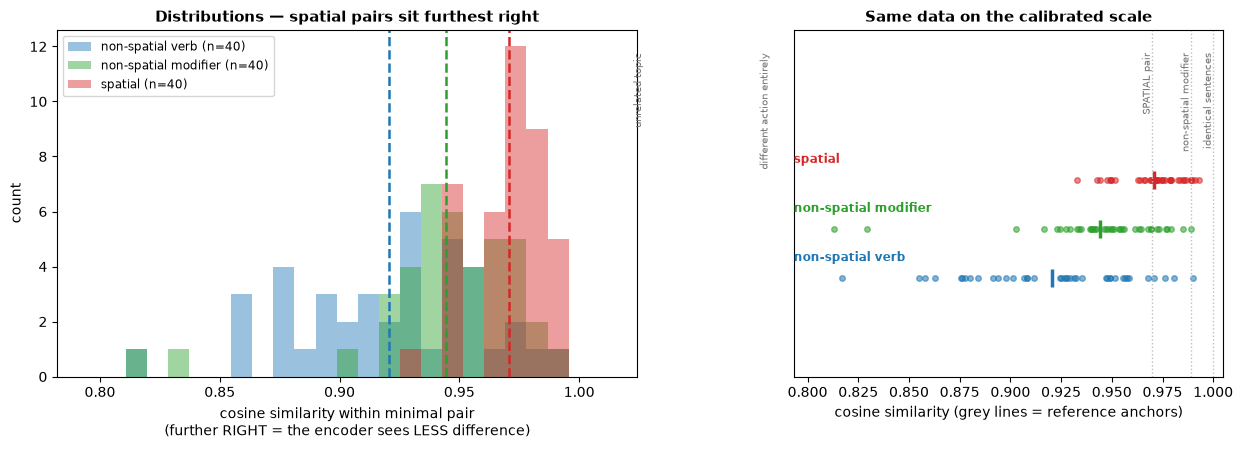

In [9]:
# Main results figure: distributions, group means on a shared scale, and the anchors for context
fig = plt.figure(figsize=(12.5, 4.6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.35, 1])

ax1 = fig.add_subplot(gs[0])
lo = min(spatial_sims.min(), verb_sims.min(), modifier_sims.min()) - 0.02
hi = max(spatial_sims.max(), verb_sims.max(), modifier_sims.max()) + 0.02
bins = np.linspace(lo, hi, 26)
for arr, lbl, c in [(verb_sims, "non-spatial verb", "tab:blue"),
                    (modifier_sims, "non-spatial modifier", "tab:green"),
                    (spatial_sims, "spatial", "tab:red")]:
    ax1.hist(arr, bins=bins, alpha=0.45, label=f"{lbl} (n={len(arr)})", color=c)
    ax1.axvline(arr.mean(), color=c, linestyle="--", linewidth=1.8)
ax1.set_xlabel("cosine similarity within minimal pair\n(further RIGHT = the encoder sees LESS difference)")
ax1.set_ylabel("count")
ax1.set_title("Distributions — spatial pairs sit furthest right", fontsize=11, weight="bold")
ax1.legend(fontsize=8.5)

ax2 = fig.add_subplot(gs[1])
ax2.set_xlim(lo, 1.005); ax2.set_ylim(0, 6); ax2.set_yticks([])
for label, v in anchor_vals.items():
    ax2.axvline(v, color="0.75", linewidth=1, linestyle=":")
    ax2.text(v, 5.6, label.split("(")[0].strip(), rotation=90, ha="right", va="top",
             fontsize=7.2, color="0.45")
for i, (arr, lbl, c) in enumerate([(spatial_sims, "spatial", "tab:red"),
                                   (modifier_sims, "non-spatial modifier", "tab:green"),
                                   (verb_sims, "non-spatial verb", "tab:blue")]):
    y = 3.4 - i * 0.85
    ax2.scatter(arr, np.full(len(arr), y), s=16, alpha=0.55, color=c)
    ax2.scatter([arr.mean()], [y], s=150, marker="|", color=c, linewidth=2.5)
    ax2.text(lo, y + 0.3, lbl, fontsize=8.5, color=c, weight="bold")
ax2.set_xlabel("cosine similarity (grey lines = reference anchors)")
ax2.set_title("Same data on the calibrated scale", fontsize=11, weight="bold")
plt.tight_layout(); plt.savefig("01_fig_results.png", dpi=110); plt.show()

### Reading the right-hand panel

The grey reference lines are the anchors from the calibration table. Notice how narrow the band is
that contains *all* of this — every group sits far from "unrelated topic". The encoder compresses
ordinary sentences into a small region, and the whole finding lives inside that region.

The spatial group (red) sits closest to "identical sentences". That is the result, stated
geometrically rather than as a p-value.

## Is the effect only in the pairs written later?

The pilot's 16 pairs came first. The other 24 were written afterwards — by which point the effect
was already known. Even with no deliberate selection, an unconscious pull toward more separable
examples would inflate the result.

The honest check is to report the two sets **separately**. If the original, untouched pilot shows
the effect on its own, the finding does not depend on anything written after the fact.

In [10]:
def subgroup_report(name, pilot_a, pilot_b, ext_a, ext_b):
    def d_and_p(a, b):
        n1, n2 = len(a), len(b)
        pooled_sd = np.sqrt(((n1-1)*a.std(ddof=1)**2 + (n2-1)*b.std(ddof=1)**2) / (n1+n2-2))
        cohens_d = (a.mean() - b.mean()) / pooled_sd
        u_one = stats.mannwhitneyu(a, b, alternative="greater")
        return cohens_d, u_one.pvalue, a.mean() - b.mean()

    d_pilot, p_pilot, gap_pilot = d_and_p(pilot_a, pilot_b)
    d_ext, p_ext, gap_ext = d_and_p(ext_a, ext_b)
    full_a, full_b = np.concatenate([pilot_a, ext_a]), np.concatenate([pilot_b, ext_b])
    d_full, p_full, gap_full = d_and_p(full_a, full_b)

    print(f"{name}:")
    print(f"  pilot     (n={len(pilot_a)}): gap={gap_pilot:+.4f}  d={d_pilot:+.3f}  one-sided p={p_pilot:.5f}")
    print(f"  extension (n={len(ext_a)}): gap={gap_ext:+.4f}  d={d_ext:+.3f}  one-sided p={p_ext:.5f}")
    print(f"  pooled    (n={len(full_a)}): gap={gap_full:+.4f}  d={d_full:+.3f}  one-sided p={p_full:.5f}")
    print(f"  ratio (extension gap / pilot gap): {gap_ext/gap_pilot:.2f}x")
    return d_pilot, p_pilot, d_ext, p_ext


pilot_spatial_sims = pair_similarities(SPATIAL_PAIRS_PILOT)
ext_spatial_sims = pair_similarities(SPATIAL_PAIRS_EXPANSION)
pilot_modifier_sims = pair_similarities(NONSPATIAL_MODIFIER_PAIRS_PILOT)
ext_modifier_sims = pair_similarities(NONSPATIAL_MODIFIER_PAIRS_EXPANSION)

d_pilot_m, p_pilot_m, d_ext_m, p_ext_m = subgroup_report(
    "Spatial vs Nonspatial-modifier",
    pilot_spatial_sims, pilot_modifier_sims, ext_spatial_sims, ext_modifier_sims,
)

both_independently_significant = (p_pilot_m < 0.05) and (p_ext_m < 0.05)
print(f"\nBoth pilot AND extension independently significant (uncorrected 0.05, one-sided)? "
      f"{'YES' if both_independently_significant else 'no'}")
if both_independently_significant:
    print("The effect is not an artifact of the extension alone -- it replicates in the "
          "untouched, originally-audited pilot set on its own, at its own (smaller, still real) "
          "effect size. The pooled n=40 number is the headline; this is what removes the "
          "'you wrote easier pairs the second time' objection rather than leaving it open.")
else:
    print("The effect does NOT independently clear significance in one of the two subsets -- "
          "report this plainly rather than let the pooled number carry a claim one subset "
          "alone would not support.")

Spatial vs Nonspatial-modifier:
  pilot     (n=16): gap=+0.0208  d=+0.678  one-sided p=0.03378
  extension (n=24): gap=+0.0303  d=+1.266  one-sided p=0.00001
  pooled    (n=40): gap=+0.0265  d=+0.995  one-sided p=0.00000
  ratio (extension gap / pilot gap): 1.46x

Both pilot AND extension independently significant (uncorrected 0.05, one-sided)? YES
The effect is not an artifact of the extension alone -- it replicates in the untouched, originally-audited pilot set on its own, at its own (smaller, still real) effect size. The pooled n=40 number is the headline; this is what removes the 'you wrote easier pairs the second time' objection rather than leaving it open.


## Does this matter for the actual dataset?

A limitation only matters in proportion to how often it is triggered. If almost no HumanML3D
caption contains spatial language, this is a curiosity. If most do, it is a property of the
benchmark.

In [11]:
import glob
import re

TEXTS_DIR = os.path.join(MDM_ROOT, "dataset", "HumanML3D", "texts")
SPATIAL_TERMS = ["left", "right", "forward", "forwards", "backward", "backwards",
                  "clockwise", "counterclockwise", "anticlockwise", "upleft",
                  "behind", "in front of"]

txt_files = sorted(glob.glob(os.path.join(TEXTS_DIR, "*.txt")))
print(f"{len(txt_files)} caption files found under {TEXTS_DIR}")

total_captions = 0
spatial_captions = 0
term_counts = {t: 0 for t in SPATIAL_TERMS}

for path in txt_files:
    with open(path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or "#" not in line:
                continue
            caption = line.split("#")[0].strip().lower()
            if not caption:
                continue
            total_captions += 1
            hit = False
            for term in SPATIAL_TERMS:
                if re.search(r"\b" + re.escape(term) + r"\b", caption):
                    term_counts[term] += 1
                    hit = True
            if hit:
                spatial_captions += 1

pct = 100 * spatial_captions / total_captions if total_captions else float("nan")
print(f"\nTotal captions scanned: {total_captions}")
print(f"Captions containing at least one spatial term: {spatial_captions} ({pct:.1f}%)")
print("\nPer-term counts (captions can contain more than one term):")
for term, count in sorted(term_counts.items(), key=lambda kv: -kv[1]):
    print(f"  {term!r:20s} {count:6d}  ({100*count/total_captions:.2f}%)")

8198 caption files found under ../third_party/motion-diffusion-model/dataset/HumanML3D/texts



Total captions scanned: 24503
Captions containing at least one spatial term: 14112 (57.6%)

Per-term counts (captions can contain more than one term):
  'right'                5942  (24.25%)
  'forward'              5544  (22.63%)
  'left'                 5327  (21.74%)
  'backwards'             875  (3.57%)
  'in front of'           704  (2.87%)
  'clockwise'             633  (2.58%)
  'forwards'              346  (1.41%)
  'counterclockwise'      247  (1.01%)
  'backward'              243  (0.99%)
  'behind'                148  (0.60%)
  'anticlockwise'          17  (0.07%)
  'upleft'                  9  (0.04%)


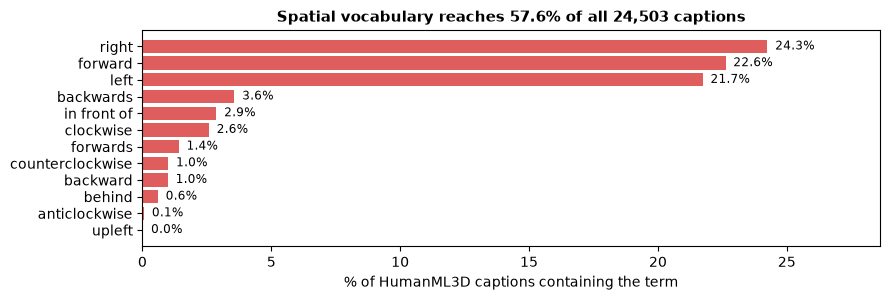

In [12]:
# How much of the corpus is affected, drawn
fig, ax = plt.subplots(figsize=(9, 3.1))
terms_sorted = sorted(term_counts.items(), key=lambda kv: -kv[1])
names = [t for t, _ in terms_sorted]
vals = [100.0 * c / total_captions for _, c in terms_sorted]
ax.barh(names[::-1], vals[::-1], color="tab:red", alpha=0.75)
ax.set_xlabel("% of HumanML3D captions containing the term")
ax.set_title(f"Spatial vocabulary reaches {100.0*spatial_captions/total_captions:.1f}% of all "
             f"{total_captions:,} captions", fontsize=11, weight="bold")
for i, v in enumerate(vals[::-1]):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8.5)
ax.set_xlim(0, max(vals) * 1.18)
plt.tight_layout(); plt.savefig("01_fig_corpus.png", dpi=110); plt.show()

## What it means

**The encoder under-separates spatial language, and the effect is not small.**

Sentences differing only by *left* vs *right* (or *forward* vs *backward*) land closer together in
CLIP's embedding space than sentences differing by a comparable non-spatial modifier — a large
effect, comfortably significant, surviving correction for the three comparisons run, and present
independently in both the original pilot pairs and the ones added later.

**Why this is worth knowing.** It relocates a suspected weakness. A model that cannot follow
"turn left" could be undertrained, or short of data, or badly tuned. This says the direction may
never have reached it: the conditioning vector barely encodes the distinction. That is a property
of a **frozen, pretrained component** — it will not improve with more training steps or more motion
data, because nothing in this pipeline updates CLIP.

**And it is not a corner case.** More than half of HumanML3D's captions contain spatial vocabulary.

**One honest caveat.** This measures the encoder, not the finished system. A downstream model could
in principle recover some directional signal from context. Showing that it does not would need a
generation experiment — deliberately out of scope here, since this project is not running new
training comparisons until its evaluation instrument is independently trusted.

In [13]:
t_two_v, t_one_v, u_two_v, u_one_v, d_v, rb_v = res_verb
t_two_m, t_one_m, u_two_m, u_one_m, d_m, rb_m = res_modifier
t_two_vm, t_one_vm, u_two_vm, u_one_vm, d_vm, rb_vm = res_verb_vs_mod

verdict_lines = []

survives_bonferroni = u_one_m < BONFERRONI_ALPHA
survives_uncorrected = u_one_m < 0.05

if survives_bonferroni:
    verdict_lines.append(
        f"CONFIRMED at Bonferroni-corrected significance (n=40/group, adequately powered): "
        f"spatial pairs (mean {spatial_sims.mean():.4f}) are measurably LESS separated than "
        f"non-spatial modifier pairs in the same syntactic slot (mean {modifier_sims.mean():.4f}). "
        f"Mann-Whitney one-sided p={u_one_m:.5f} (two-sided p={u_two_m:.5f}), clears the "
        f"Bonferroni threshold ({BONFERRONI_ALPHA:.4f}) for the 3 comparisons run. "
        f"Direct Cohen's d={d_m:+.3f}."
    )
elif survives_uncorrected:
    verdict_lines.append(
        f"PARTIALLY CONFIRMED: spatial vs modifier clears uncorrected alpha=0.05 one-sided "
        f"(p={u_one_m:.5f}, two-sided p={u_two_m:.5f}) but NOT the Bonferroni-corrected threshold "
        f"({BONFERRONI_ALPHA:.4f}) for the 3 comparisons actually run. Reported as a real but "
        f"fragile signal at n=40, not a confident confirmation -- this is the honest reading, "
        f"not the headline reading."
    )
else:
    verdict_lines.append(
        f"NOT CONFIRMED at n=40: spatial vs modifier p={u_one_m:.5f} one-sided "
        f"(two-sided p={u_two_m:.5f}). The round-1 finding at n=16 does not survive the adequately "
        f"-powered re-run. This would be reported as the effect vanishing, not salvaged."
    )

verdict_lines.append(
    f"\nPilot-vs-extension check: pilot alone (n=16) one-sided p={p_pilot_m:.5f} "
    f"(d={d_pilot_m:+.3f}), extension alone (n=24) one-sided p={p_ext_m:.5f} (d={d_ext_m:+.3f}) -- "
    + ("both independently significant, so the pooled result is not an artifact of writing "
       "easier-to-separate pairs after seeing the pilot's own result." if (p_pilot_m < 0.05 and p_ext_m < 0.05) else
       "NOT both independently significant -- the pooled headline should be read with that caveat.")
)

verdict_lines.append(
    f"\nConfound check (verb vs modifier), two-sided p={u_two_vm:.5f}: " +
    ("still no difference between the two non-spatial groups -- the spatial effect above is "
     "attributable to spatial-ness alone, with no residual word-class confound to account for."
     if u_two_vm >= 0.05 else
     f"a real difference now shows between the two non-spatial groups (verb mean "
     f"{verb_sims.mean():.4f} vs modifier mean {modifier_sims.mean():.4f}, d={d_vm:+.3f}) -- "
     "at n=40, modifiers in general separate somewhat worse than verbs, so the clean "
     "'no confound at all' story from the n=16 pilot does not fully survive. This does NOT "
     "invalidate the primary spatial-vs-modifier result above: that comparison is already "
     "matched on word class (modifier vs modifier, same syntactic slot), so it does not depend "
     "on verbs and modifiers being equivalent -- it only needed the SAME non-spatial word class "
     "as the spatial group, which it has. The verb-vs-modifier gap is a separate, secondary "
     "finding (CLIP may separate modifiers worse than verbs generally, independent of "
     "spatial-ness) worth its own follow-up, not a defect in the primary test.")
)

verdict_lines.append(
    f"\nFor reference, spatial vs verb (the original, more separated comparison): one-sided "
    f"p={u_one_v:.6f}, two-sided p={u_two_v:.6f}, Cohen's d={d_v:+.3f}."
)

verdict_lines.append(
    f"\nCorpus footprint: {pct:.1f}% of {total_captions} HumanML3D captions contain at least one "
    f"of {SPATIAL_TERMS}. " +
    ("This is a narrow slice of the benchmark, not a dominant failure mode." if pct < 10 else
     "This is not a narrow footnote -- a majority of the benchmark's own captions use language "
     "this encoder may not distinguish.")
)

print("\n".join(verdict_lines))

CONFIRMED at Bonferroni-corrected significance (n=40/group, adequately powered): spatial pairs (mean 0.9707) are measurably LESS separated than non-spatial modifier pairs in the same syntactic slot (mean 0.9442). Mann-Whitney one-sided p=0.00000 (two-sided p=0.00001), clears the Bonferroni threshold (0.0167) for the 3 comparisons run. Direct Cohen's d=+0.995.

Pilot-vs-extension check: pilot alone (n=16) one-sided p=0.03378 (d=+0.678), extension alone (n=24) one-sided p=0.00001 (d=+1.266) -- both independently significant, so the pooled result is not an artifact of writing easier-to-separate pairs after seeing the pilot's own result.

Confound check (verb vs modifier), two-sided p=0.00244: a real difference now shows between the two non-spatial groups (verb mean 0.9206 vs modifier mean 0.9442, d=-0.639) -- at n=40, modifiers in general separate somewhat worse than verbs, so the clean 'no confound at all' story from the n=16 pilot does not fully survive. This does NOT invalidate the pri

## What would change my mind

Stated up front so the claim stays falsifiable:

1. **A different encoder showing the same pattern.** If *every* text encoder compresses one-word
   swaps this way, the finding is about minimal pairs, not about spatial language. Running the same
   three groups through a sentence-transformer would test this — the single most valuable follow-up.
2. **Sensitivity to sentence frames.** All pairs here use a narrow set of templates. Heavier
   paraphrase variety could shrink the gap.
3. **Recovery downstream.** If a trained model reliably produced correct handedness despite this,
   the encoder's compression would be less consequential than it appears.
4. **Token-level rescue.** This probes the *pooled* sentence embedding, which is what MDM uses. The
   per-token features may retain more; a model wired to use them might not inherit the limitation.

None of these are addressed here. Each is cheap, and (1) needs no training.